In [30]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media

import robotic as ry

import data_tools
import sim_wrappers as sim


In [31]:
# scene_path = "/home/sayantan/Downloads/fingerRamp.g"
# xml_path = "/home/sayantan/repos/tub/proj/explore/configs/fingerRamp.xml"
# config_path = "/home/sayantan/repos/tub/proj/explore/configs/fingerRamp_onRamp.h5"

scene_path = "/home/sayantan/repos/tub/proj/25-diverseKomoManip/scenes/oneFingerBall.yml"
xml_path = "/home/sayantan/repos/tub/proj/25-diverseKomoManip/scenes/oneFingerBall.xml"
config_path = "/home/sayantan/repos/tub/proj/25-diverseKomoManip/data/fingerBall/configs_oneFingerBall.h5"

In [32]:
from sim_wrappers.mujoco_gym import MujocoGymGoal

def feature_map(qpos, qvel, scale_obj=2., scale_q=1.):

    # object position - last 3 positions of qpos
    z_obj = qpos[-3:]

    # robot angles (=finger position) - everything before last 3 positions
    z_q = qpos[:-3]

    # scaled concatenation
    return np.concat((scale_obj*z_obj, scale_q*z_q))
        
env = MujocoGymGoal(
        config_path=config_path,
        xml_path=xml_path,
        scene_path=scene_path,
        sparse_r_thr=10.0,
        feature_map=feature_map,
        engine='mujoco',
        start_id=-1,
        goal_id=-1,
        time_limit=2,
        camera='cam0',
        ctrl_lim=0.1,
        num_ctrl_pts=5,
        goal_not_on_table=False
    )

env.render_mode = 'rgb_array'

-- initializing MjSim with 1 free objects and joint dimension 3 (mj qpos:10 ctrl:3)


start_id: 5059, goal_id: 8568
dict_keys(['observation', 'achieved_goal', 'desired_goal']) {'start_id': 5059, 'goal_id': 8568}


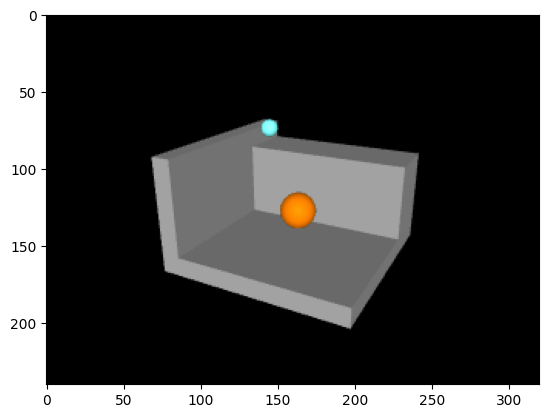

In [33]:
obs_dict, info = env.reset()
print(obs_dict.keys(), info)
frame = env.render()
plt.imshow(frame)

In [34]:
import mediapy as media
frames = []
obs_dict, info = env.reset()
frames.append(env.render())
for i in range(100):
    random_action = action=env.action_space.sample()
    obs_dict, reward, terminated, truncated, info = env.step(random_action)
    frames.append(env.render())

media.show_video(frames, fps=10)


start_id: 6010, goal_id: 2265


This browser does not support the video tag.


In [35]:
a = np.zeros((5,19))
d = np.ones((5,19))
o = np.zeros((5,38))

info = {}

r = env.compute_reward(a,d,info)

print(r.shape)

(5,)


In [36]:
from stable_baselines3.common.env_checker import check_env

check_env(env, warn=True)

We detected your env to be a GoalEnv because `env.compute_reward()` was defined.
If it's not the case, please rename `env.compute_reward()` to something else to avoid False positives.
start_id: 8390, goal_id: 8264
start_id: 9754, goal_id: 8
start_id: 2544, goal_id: 4018
start_id: 8447, goal_id: 835


/home/sayantan/repos/tub/proj/sim-wrappers/.venv/lib/python3.12/site-packages/stable_baselines3/common/env_checker.py:462: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


In [37]:
pi = lambda obs, t : env.action_space.sample()
traj = env.rollout(pi=pi, verbose=1, return_data=True)


start_id: 1427, goal_id: 8477
total (non-discounted) return: 9.0


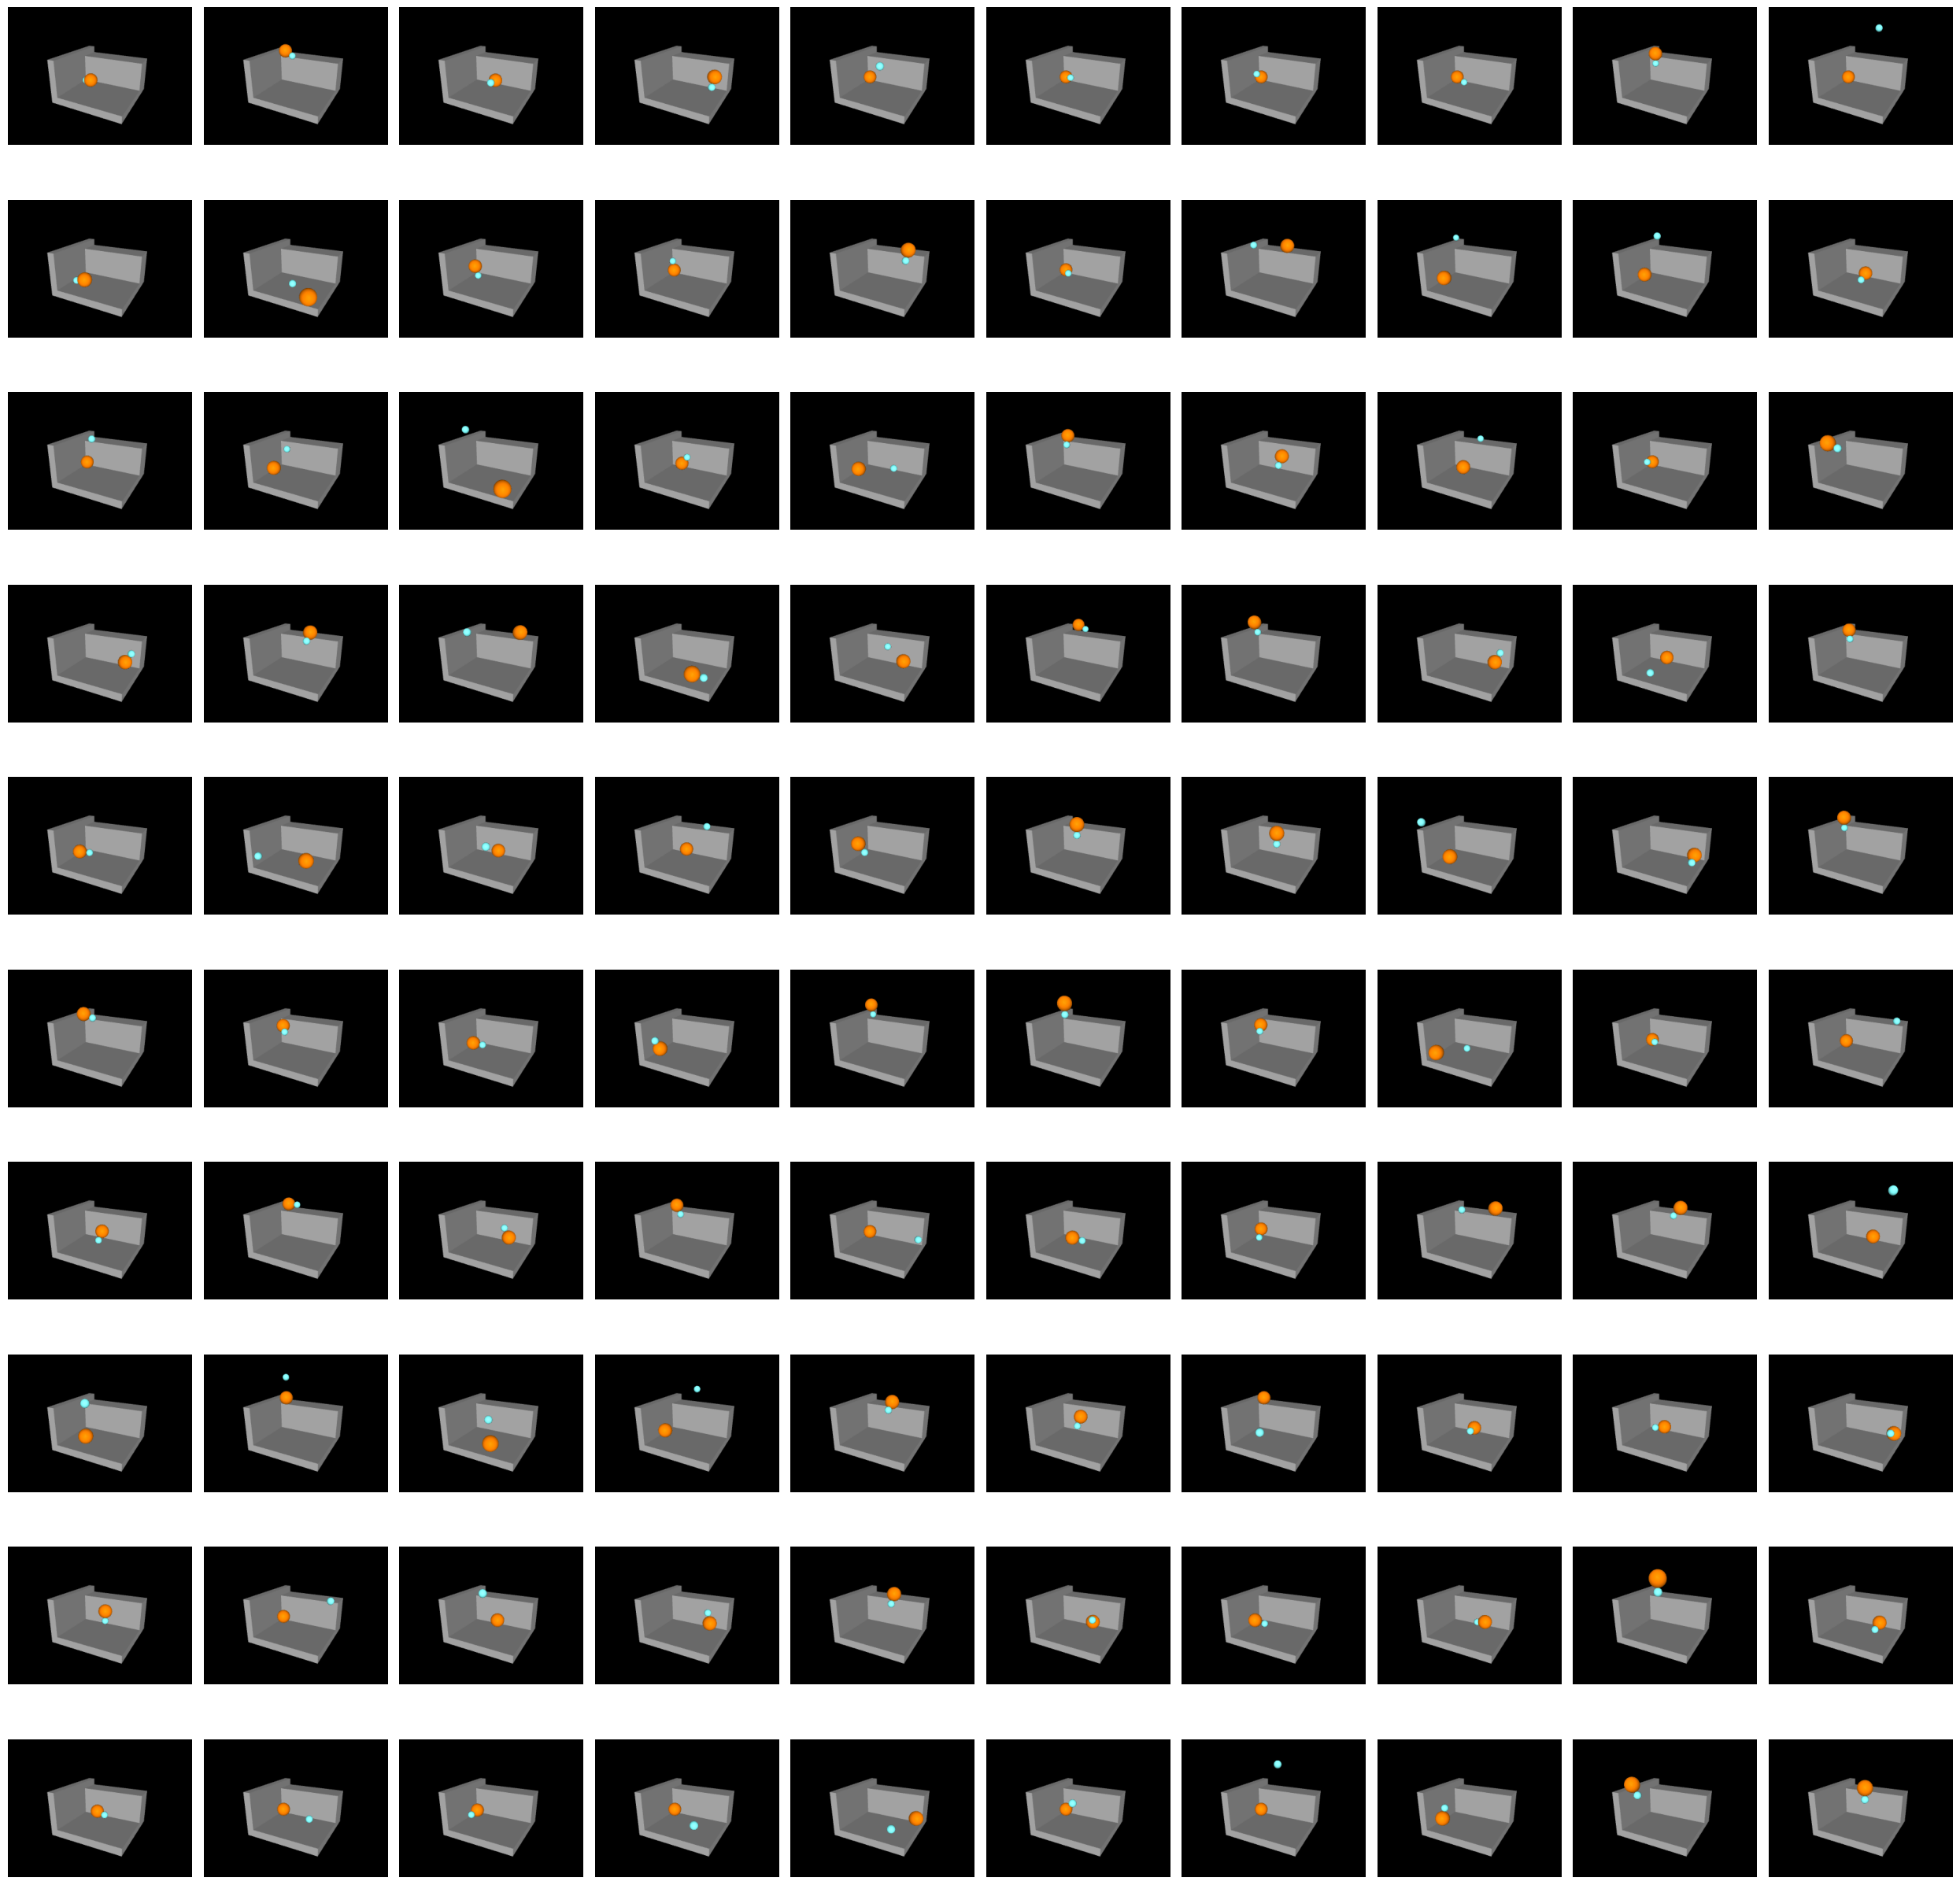

In [ ]:
# Checking initial configs

fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(25, 25))  # adjust size for visibility
env.verbose = 0
for i in range(10):
    for j in range(10):
        _ = env.reset()
        frame = env.render()
        axes[i, j].imshow(frame)
        axes[i, j].axis('off')  # hide axes
plt.tight_layout()

{'start_id': 1893, 'goal_id': 5586}


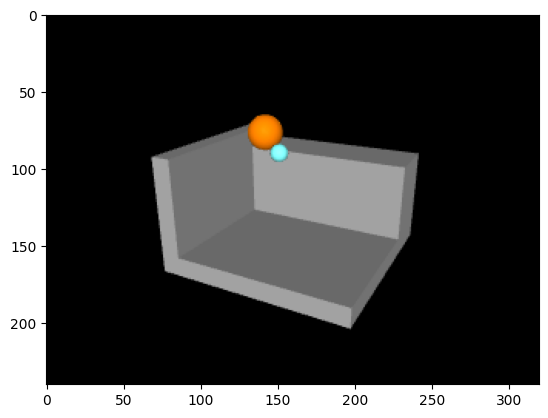

In [538]:
# Check that goals are not on the table

env.goal_not_on_table = True
obs_dict, info = env.reset()
env.set_sim_state_to_config(env.config.q[info['goal_id']])
plt.imshow(env.render())
print(info)

260 5726


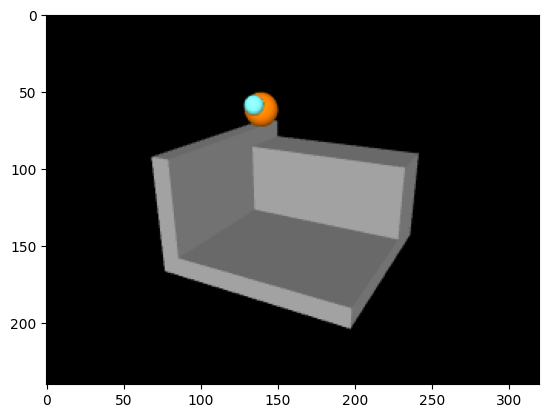

In [450]:
# Check that goals are not on the table

env.goal_not_on_table = True

def get_random_task(env, goal_not_on_table=True, fixed_goal=None):
    while(True):
        task = np.random.randint(env.config.q.shape[0]-1, size=2)
        if fixed_goal is not None:
            task[1] = fixed_goal
        if task[0]>=task[1]:
            task[0] += 1
        if goal_not_on_table:
            if 5 not in env.config.contacts[task[1]]:
                break
        else:
            break
    return task.tolist()

sid, eid = get_random_task(env)
env.set_sim_state_to_config(env.config.q[eid])
plt.imshow(env.render())
print(sid, eid)